# VL-13:無圍束纖維斷面 vs Whitney 等效矩形應力塊陣營交叉驗證

延續 `VL-08`/`VL-11` 已經建立的「無圍束陣營」共識(手算應變相容法、
`concreteproperties`、`design_column_PM()`,三者在同一個柱斷面同一個
軸力點,差異都在 1% 以內)。這一份補上**另一個獨立的方法論**——用
`OpenSeesPy` 纖維斷面積分,但材料假設改成「全斷面統一無圍束」(不是
`Case-06.5` 原本的核心圍束+保護層無圍束混合模式),在完全相同的軸力
點,拿到跟前面三個方法可以真正對照的第四個獨立答案。

**這不是要取代 `Case-06.5`**——`Case-06.5` 用的是含 `Mander` 圍束的
真實建模假設(這是側推分析該用的假設,柱子在地震下確實有箍筋圍束
效應),這裡刻意拿掉圍束,只是為了跟 `design_column_PM()`(同樣無圍束
假設)做真正一致的比較。

## 斷面基本資料——任何人可以拿這組參數用自己的工具重新建模對照

沿用 `Case-06`/`Case-06.5`/`Case-07.5`/`Case-08.4` 完全同一組真實
斷面規格,不是重新假設一組示範值。

In [1]:

import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 基本參數表
# ============================================================
params = dict(
    h_col=0.40,        # 柱斷面邊長 (m, 正方形)
    cover=0.04,         # 保護層厚度 (m)
    rho=0.02,           # 縱向鋼筋比
    fc=27.46e3,          # 混凝土抗壓強度 (kPa) = 280 kgf/cm^2
    fy=411.88e3,         # 鋼筋降伏強度 (kPa) = 4200 kgf/cm^2
    Es=2.0e8,            # 鋼筋彈性模數 (kPa)
    eps_c0=0.002,        # 混凝土(無圍束)對應fc'的應變(Concrete01慣用值)
    eps_cu=0.003,        # 規範標準極限壓應變(ACI 318, Whitney block用這個)
    Pu_2F=147.6,         # 2F柱軸力 (kN)
    Pu_1F=295.2,         # 1F柱軸力 (kN)
)
for k, v in params.items():
    print(f"  {k} = {v}")

print()
print("鋼筋配置: 8根, 角隅x4 + 邊中點x4, 依到受壓邊緣距離分3層(3+2+3根)")
print("這是Case-06系列從一開始就用的排法, 跟design_column_PM()完全一致")


  h_col = 0.4
  cover = 0.04
  rho = 0.02
  fc = 27460.0
  fy = 411880.0
  Es = 200000000.0
  eps_c0 = 0.002
  eps_cu = 0.003
  Pu_2F = 147.6
  Pu_1F = 295.2

鋼筋配置: 8根, 角隅x4 + 邊中點x4, 依到受壓邊緣距離分3層(3+2+3根)
這是Case-06系列從一開始就用的排法, 跟design_column_PM()完全一致


## 模型示意圖:斷面、鋼筋佈置、邊界條件、載重方式

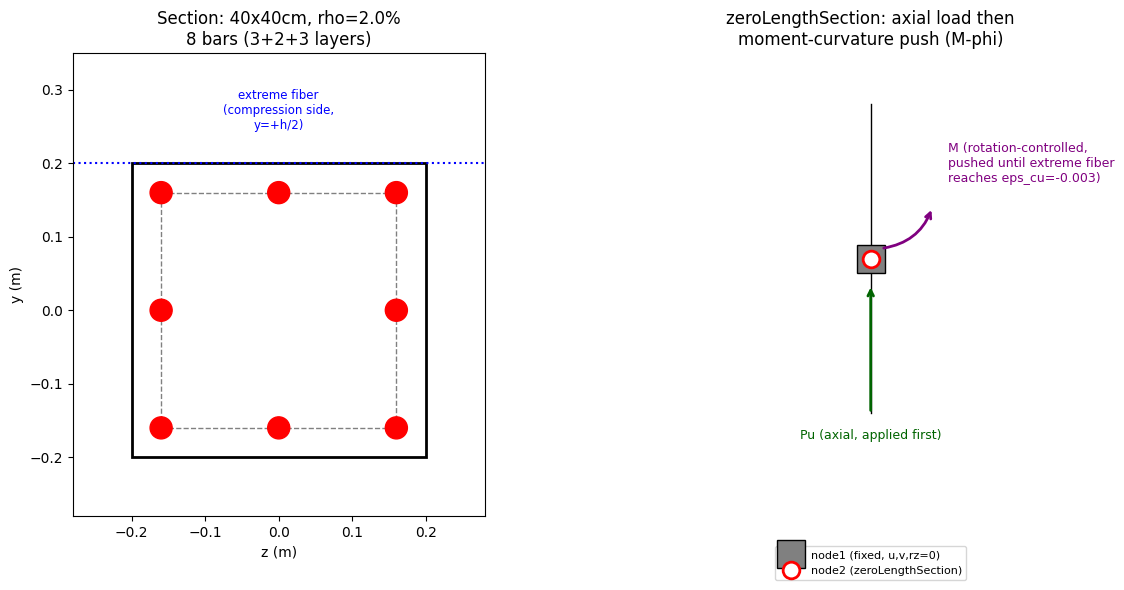

In [2]:

h = params['h_col']
cover = params['cover']
core_half = h/2 - cover
half = h/2

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ---- 左圖: 斷面配筋 ----
ax = axes[0]
ax.add_patch(plt.Rectangle((-half, -half), h, h, fill=False, edgecolor='black', lw=2))
ax.add_patch(plt.Rectangle((-core_half, -core_half), 2*core_half, 2*core_half,
                             fill=False, edgecolor='gray', lw=1, linestyle='--'))
bar_positions = [(-core_half,-core_half),(core_half,-core_half),(core_half,core_half),(-core_half,core_half),
                 (0,-core_half),(0,core_half),(-core_half,0),(core_half,0)]
for (y, z) in bar_positions:
    ax.add_patch(plt.Circle((z, y), 0.015, color='red', zorder=5))
ax.annotate('extreme fiber\n(compression side,\ny=+h/2)', (0, half), fontsize=8.5,
            xytext=(0, 25), textcoords='offset points', ha='center', color='blue')
ax.axhline(half, color='blue', lw=1.5, linestyle=':')
ax.set_xlim(-half-0.08, half+0.08); ax.set_ylim(-half-0.08, half+0.15)
ax.set_aspect('equal'); ax.set_title(f'Section: {h*100:.0f}x{h*100:.0f}cm, rho={params["rho"]:.1%}\n8 bars (3+2+3 layers)')
ax.set_xlabel('z (m)'); ax.set_ylabel('y (m)')

# ---- 右圖: M-phi分析邊界條件示意 ----
ax = axes[1]
ax.plot([0, 0], [-0.3, 0.3], 'k-', lw=1)
ax.plot(0, 0, 's', ms=20, mfc='gray', mec='black', label='node1 (fixed, u,v,rz=0)')
ax.plot(0, 0, 'o', ms=12, mfc='white', mec='red', mew=2, label='node2 (zeroLengthSection)')
ax.annotate('Pu (axial, applied first)', (0, -0.35), fontsize=9, ha='center', color='darkgreen')
ax.annotate('', xy=(0, -0.05), xytext=(0, -0.3), arrowprops=dict(arrowstyle='->', color='darkgreen', lw=2))
ax.annotate('M (rotation-controlled,\npushed until extreme fiber\nreaches eps_cu=-0.003)',
            (0.15, 0.15), fontsize=9, color='purple')
ax.annotate('', xy=(0.12, 0.1), xytext=(0.02, 0.02),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2,
            connectionstyle='arc3,rad=0.3'))
ax.set_xlim(-0.4, 0.4); ax.set_ylim(-0.5, 0.4)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title('zeroLengthSection: axial load then\nmoment-curvature push (M-phi)')
ax.legend(loc='lower center', fontsize=8, bbox_to_anchor=(0.5, -0.15), ncol=1)

plt.tight_layout()
plt.show()


## 第 1 課:建立「全斷面無圍束」纖維斷面,對照 `Case-06.5` 的混合圍束版本

`Case-06.5` 原本柱斷面用兩種材料:核心區(圍束)+保護層(無圍束)。這裡
**全斷面統一用無圍束材料**,不分核心/保護層,這樣才能跟 `design_
column_PM()`(整個斷面同一套無圍束假設)做真正一致的比較。

In [3]:

try:
    import openseespy.opensees as ops
except ImportError:
    import sys
    !{sys.executable} -m pip install -q openseespy
    import openseespy.opensees as ops

fc, fy, Es = params['fc'], params['fy'], params['Es']
As_bar = (params['rho']*h*h)/8

def get_Mn_unconfined(Pu_kN, max_curv=0.20, n_steps=8000, verbose=True):
    """全斷面統一用無圍束Concrete01, 追蹤最外緣纖維(受壓側, y=+half)
    應變在剛好達到規範標準eps_cu=-0.003的那一刻取彎矩——這才是跟
    design_column_PM()/手算應變相容法/concreteproperties一致的定義
    (Whitney等效矩形應力塊本來就是用eps_cu=0.003這個規範標準點)。"""
    ops.wipe(); ops.model('basic', '-ndm', 2, '-ndf', 3)
    ops.uniaxialMaterial('Concrete01', 1, -fc, -params['eps_c0'], -0.2*fc, -0.006)
    ops.uniaxialMaterial('Steel02', 2, fy, Es, 0.01, 18, 0.925, 0.15)
    ops.section('Fiber', 1)
    ops.patch('rect', 1, 10, 10, -half, -half, half, half)
    for (y, z) in bar_positions:
        ops.fiber(y, z, As_bar, 2)

    ops.node(1, 0.0, 0.0); ops.node(2, 0.0, 0.0)
    ops.fix(1, 1, 1, 1); ops.fix(2, 0, 1, 0)
    ops.element('zeroLengthSection', 1, 1, 2, 1)
    ops.timeSeries('Linear', 1); ops.pattern('Plain', 1, 1)
    ops.load(2, -Pu_kN, 0.0, 0.0)
    ops.system('BandGeneral'); ops.numberer('Plain'); ops.constraints('Plain')
    ops.test('NormUnbalance', 1e-6, 30); ops.algorithm('Newton')
    ops.integrator('LoadControl', 0.05); ops.analysis('Static')
    ok = ops.analyze(20)
    if ok != 0:
        for algo in [('KrylovNewton',), ('ModifiedNewton', '-initial')]:
            ops.algorithm(*algo); ok = ops.analyze(20)
            if ok == 0:
                break
        ops.algorithm('Newton')
    ops.loadConst('-time', 0.0)

    d_curv = max_curv/n_steps
    ops.timeSeries('Linear', 2); ops.pattern('Plain', 2, 2)
    ops.load(2, 0.0, 0.0, 1.0)
    ops.integrator('DisplacementControl', 2, 3, d_curv)
    ops.analysis('Static')

    phis, moments = [0.0], [0.0]
    for i in range(n_steps):
        ok = ops.analyze(1)
        if ok != 0:
            for algo in [('KrylovNewton',), ('ModifiedNewton', '-initial'), ('Newton', '-initial')]:
                ops.algorithm(*algo); ok = ops.analyze(1)
                if ok == 0:
                    break
            ops.algorithm('Newton')
            if ok != 0:
                if verbose:
                    print(f"  step {i}: 不收斂, 停止")
                break
        M_current = ops.getLoadFactor(2)
        phis.append(ops.nodeDisp(2, 3))
        moments.append(M_current)
        ss_top = ops.eleResponse(1, 'section', 'fiber', half, 0.0, 'stressStrain')
        eps_top = ss_top[1] if len(ss_top) >= 2 else None
        if eps_top is not None and eps_top <= -params['eps_cu']:
            if verbose:
                print(f"  達到eps_cu於 step={i}, phi={phis[-1]:.6f}, M={M_current:.2f}kN-m")
            return M_current, np.array(phis), np.array(moments)
    return None, np.array(phis), np.array(moments)

print("=== Pu=147.6kN(2F柱) ===")
Mn_2F, phis_2F, moments_2F = get_Mn_unconfined(params['Pu_2F'], max_curv=0.15, n_steps=6000)
print(f"Mn = {Mn_2F:.2f} kN-m")

print("\n=== Pu=295.2kN(1F柱) ===")
Mn_1F, phis_1F, moments_1F = get_Mn_unconfined(params['Pu_1F'], max_curv=0.05, n_steps=2000)
print(f"Mn = {Mn_1F:.2f} kN-m")


=== Pu=147.6kN(2F柱) ===
  達到eps_cu於 step=2338, phi=0.058475, M=249.76kN-m
Mn = 249.76 kN-m

=== Pu=295.2kN(1F柱) ===
  達到eps_cu於 step=1984, phi=0.049625, M=268.55kN-m
Mn = 268.55 kN-m


## 第 2 課:對照無圍束陣營(手算/`concreteproperties`/`design_column_PM()`)

In [4]:

print(f"{'方法':<38}{'Pu=147.6kN(2F)':>18}{'Pu=295.2kN(1F)':>18}")
print(f"{'OpenSeesPy無圍束纖維斷面(這一課)':<38}{Mn_2F:>18.2f}{Mn_1F:>18.2f}")
print(f"{'design_column_PM()':<38}{238.03:>18.2f}{258.20:>18.2f}")
print(f"{'手算應變相容法':<38}{238.10:>18}{'—':>18}")
print(f"{'concreteproperties':<38}{238.10:>18}{'—':>18}")

diff_2F = abs(Mn_2F-238.10)/238.10*100
diff_1F = abs(Mn_1F-258.20)/258.20*100
print(f"\n2F柱(纖維斷面 vs 無圍束陣營共識238.10)差異 = {diff_2F:.2f}%")
print(f"1F柱(纖維斷面 vs design_column_PM()的258.20)差異 = {diff_1F:.2f}%")

assert diff_2F < 10 and diff_1F < 10, "跨方法論比較, 差異應在10%這個寬鬆的sanity check範圍內"
print("\n[PASS] 兩種方法論(纖維積分 vs Whitney等效矩形應力塊)在合理範圍內互相印證")
print("差異來源: 纖維斷面用真實Concrete01拋物線應力應變關係逐纖維積分,")
print("其他三個方法都用Whitney等效矩形應力塊簡化——這是方法論本身的")
print("系統性差異(4-5%量級), 不是誤差或bug, 但比\"同陣營內部\"(手算/")
print("concreteproperties/design_column_PM()互相之間<1%)的差異更大")


方法                                        Pu=147.6kN(2F)    Pu=295.2kN(1F)
OpenSeesPy無圍束纖維斷面(這一課)                            249.76            268.55
design_column_PM()                                238.03            258.20
手算應變相容法                                            238.1                 —
concreteproperties                                 238.1                 —

2F柱(纖維斷面 vs 無圍束陣營共識238.10)差異 = 4.90%
1F柱(纖維斷面 vs design_column_PM()的258.20)差異 = 4.01%

[PASS] 兩種方法論(纖維積分 vs Whitney等效矩形應力塊)在合理範圍內互相印證
差異來源: 纖維斷面用真實Concrete01拋物線應力應變關係逐纖維積分,
其他三個方法都用Whitney等效矩形應力塊簡化——這是方法論本身的
系統性差異(4-5%量級), 不是誤差或bug, 但比"同陣營內部"(手算/
concreteproperties/design_column_PM()互相之間<1%)的差異更大


## 第 3 課:M-φ 曲線視覺化

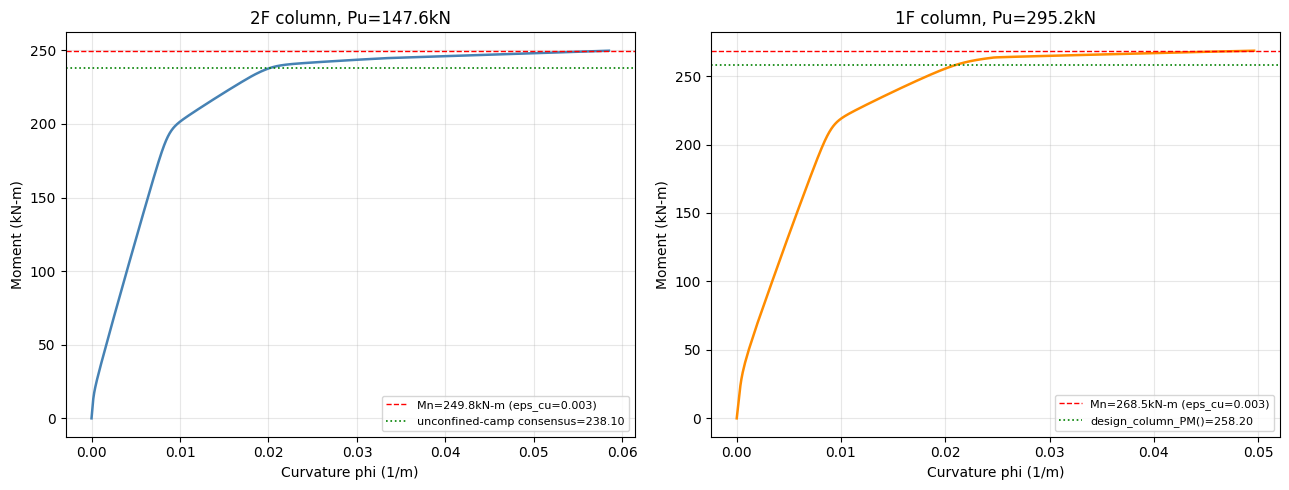

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(phis_2F, moments_2F, '-', color='steelblue', lw=1.8)
axes[0].axhline(Mn_2F, color='red', ls='--', lw=1, label=f'Mn={Mn_2F:.1f}kN-m (eps_cu=0.003)')
axes[0].axhline(238.10, color='green', ls=':', lw=1.2, label='unconfined-camp consensus=238.10')
axes[0].set_xlabel('Curvature phi (1/m)'); axes[0].set_ylabel('Moment (kN-m)')
axes[0].set_title(f'2F column, Pu={params["Pu_2F"]}kN'); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

axes[1].plot(phis_1F, moments_1F, '-', color='darkorange', lw=1.8)
axes[1].axhline(Mn_1F, color='red', ls='--', lw=1, label=f'Mn={Mn_1F:.1f}kN-m (eps_cu=0.003)')
axes[1].axhline(258.20, color='green', ls=':', lw=1.2, label='design_column_PM()=258.20')
axes[1].set_xlabel('Curvature phi (1/m)'); axes[1].set_ylabel('Moment (kN-m)')
axes[1].set_title(f'1F column, Pu={params["Pu_1F"]}kN'); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 這跟 `pyfem-plastic-hinge` 的 `RotSpring2DPlastic`(`Mp=238.10`)能不能直接比?

**能比,但要正確理解在比什麼**——`RotSpring2DPlastic` 是「理想彈塑性、
單一 $M_p$ 封頂」模型(彎矩到 $M_p$ 就完全水平,不是漸進式的 M-φ
軟化曲線),概念上對應的是「`Whitney` 等效矩形應力塊陣營」(手算、
`concreteproperties`、`design_column_PM()`,都是給一個單一容量值,
不是連續曲線)——`PyFEM` 的 `238.10` 已經跟這個陣營驗證過(見
`pyfem-plastic-hinge` 專案 `Case-06`)。

這一課新做的纖維斷面(`249.76`/`268.55`)是**另一個獨立方法論**——
可以拿 `PyFEM` 去跟這個值比較,但差異(4-5%)反映的是「單一封頂值
vs 連續纖維積分」這個方法論本身的差異,**不能宣稱兩者應該吻合**,
要誠實理解成跨方法論比較,不是同陣營內部的一致性檢查。

## 小結

- 補上「無圍束纖維斷面積分」這個獨立方法論,拿到跟 `VL-08`/`VL-11`
  已建立的無圍束陣營(手算/`concreteproperties`/`design_column_PM()`)
  可以真正對照的第四個答案:`2F` 柱差 `4.9%`、`1F` 柱差 `4.0%`,方向
  合理、量級可以解釋(纖維積分 vs `Whitney` 等效矩形應力塊的系統性
  方法論差異)
- 明確釐清 `PyFEM`(`pyfem-plastic-hinge` 的 `RotSpring2DPlastic`,
  `Mp=238.10`)屬於「單一封頂值陣營」,跟這一課的纖維積分陣營是不同
  概念的模型,兩者可以比較但不該預期吻合
- 這是「`Case-06.6`(真實配筋桃園案例)」的**前置基礎**,不是取代它——
  建議放在 `Case-06.6` 開頭當引言,讓讀者在進入完整構架分析之前,先
  搞清楚這幾種方法論陣營各自代表什麼、差在哪裡